In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
from scipy.interpolate import interp1d
from scipy.optimize import root
import importlib
import classy
from scipy.special import sici
from classy import Class
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern"],
})

In [5]:
h = 0.67810
_H0_ = 3.336e-04 * h
_ev_to_HO_ = 1.56e29 / _H0_
common_settings = {
'omega_b':0.0223828,
'h':h,
'z_reio':7.6711,
'YHe':0.25,
'perturbations_verbose':1,
'background_verbose':3,
'output':'mPk, mTk',
'P_k_max_1/Mpc':10,
'z_max_pk':1000,
'format':'class',
'A_s': 2.e-9,
}

In [3]:
# ChatGPT says that 1 eV = 4.827e19 invMpc
chiCDM = Class()
chiCDM.set(common_settings)

m_ev = 1.e-22
fx = 0.1
chiCDM.set({
    'omega_cdm': 0.12,
    'scf_potential': 'axion',
    'n_axion': 1,
    'f_axion': 0.4,  # in units of mpl
    'Omega_scf' : ((fx/(1-fx))*(0.12+0.02238))/h/h,
    'm_axion': m_ev * _ev_to_HO_,  # in units of H0
    'tol_shooting_deltax': 1e-4,
    'tol_shooting_deltaF': 1e-4,
    'scf_parameters': '0.05,0.0',  # note: if Omega_scf is set, the parameter entry corresponding to scf_tuning_index is ignored and used for shooting.
    'scf_tuning_index': 0,  # in this example, we shoot over theta_ini in order to adjust Omega_scf.
    'scf_evolve_as_fluid': 'yes',  # if set to yes, will switch for fluid when threshold_scf_fluid_m_over_H is met
    'scf_evolve_like_axionCAMB': 'yes',  # fluid all the time in perts, the option no is currently bugging, to be debugged
    'threshold_scf_fluid_m_over_H': 3,  # threshold_scf_fluid_m_over_H controls when to switch to fluid
    'do_shooting': 'yes',  # controls shooting in general; e.g. theta_s
    'do_shooting_scf': 'yes',  # necessary when log10_axion_ac & log10_fraction_axion_ac are chosen
    'scf_has_perturbations': 'yes',  # for pedagogical purposes only
    'use_big_theta_scf': 'no',  # in perts with the fluid it is often more stable to follow the heat flux rather "Big Theta=(1+w)*Theta" than the velocity divergence "Theta"
    'use_delta_scf_over_1plusw': 'no',
    'attractor_ic_scf': 'no',  # some specific IC for tracker potentials
    'evolver': 0,
    'background_verbose':2
})

# chiCDM.compute()
#get the growth factor of a LCDM equivalent
nuCDM = Class()

nuCDM.set(common_settings)


True

Running CLASS version v3.2.0
Computing background
Chose ndf15 as generic_evolver
 -> age = 13.368997 Gyr
 -> conformal age = 13576.578870 Mpc
 -> H0 = 67.810000 km/s/Mpc
 -> N_eff = 3.044 (summed over all species that are non-relativistic at early times) 
 -> radiation/matter equality at z = 3781.415108
    corresponding to conformal time = 101.527426 Mpc
 ---------------------------- Budget equation ----------------------- 
 ---> Nonrelativistic Species 
-> Bayrons                        Omega = 0.0486773       , omega = 0.0223828      
-> Cold Dark Matter               Omega = 0.260972        , omega = 0.12           
-> Axion DM                       Omega = 0.0344048       , omega = 0.01582        
 ---> Relativistic Species 
-> Photons                        Omega = 5.37815e-05     , omega = 2.47298e-05    
-> Ultra-relativistic relics      Omega = 3.71799e-05     , omega = 1.70961e-05    
 ---> Other Content 
-> Cosmological Constant          Omega = 0.655855        , omega = 0.3

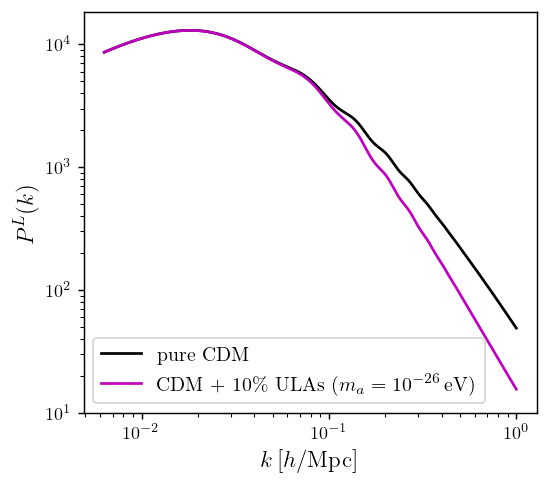

In [5]:

chiCDM.set({
    'm_axion': 1.e-10 * _ev_to_HO_,  # in units of H0
})
chiCDM.compute()


kk = np.logspace(-2.2,0,200); h = chiCDM.h(); Pk_list=[]
plt.figure(figsize=(4.5,4), dpi=130)

Pk = [chiCDM.pk_lin(k*h,0.5)*h**3 for k in kk]
plt.loglog(kk, Pk, 'k', label=f'pure CDM')

chiCDM.set({
    'm_axion': 1.e-26 * _ev_to_HO_,  # in units of H0
})
chiCDM.compute()
Pk = [chiCDM.pk_lin(k*h,0.5)*h**3 for k in kk]

plt.loglog(kk, Pk, 'm', label=r'CDM + $10\%$ ULAs ($m_a=10^{-26}\,\mathrm{eV})$')

# Mnu = 1.
# omega_nu = Mnu/93.14
# omega_c = 0.142-0.02238-omega_nu

# nuCDM.set({
#     'omega_cdm': omega_c,
#     'N_ncdm':1,
#     'm_ncdm':'1.',
#     'ncdm_fluid_approximation':0.,
#     'background_verbose':3,
#     'A_s':1.75e-9
# })

# nuCDM.compute()

# Pk = [nuCDM.pk_lin(k*h,0.5)*h**3 for k in kk]

# # plt.loglog(kk, Pk, 'g', label=r'CDM + $M_\nu$')

plt.xlabel(r'$k\,[h/\mathrm{Mpc}]$', fontsize=13)
plt.ylabel(r'$P^L(k)$', fontsize=13)
plt.ylim([1.e1,None])
plt.legend(loc='lower left', fontsize=11)

# plt.ylim([1.,None])

plt.show()


In [16]:
zeval = 0.5
m_ev = 1.e-25
kJest =8.4e12 * pow(m_ev/h,1/2) * (1/(1+zeval))**0.25
kdropest =5.2e-2 * pow(m_ev*_ev_to_HO_/1.e6,1/2)
print(kJest, kdropest)

2.914805626028173 0.4318229795062473


In [11]:
m_ev*_ev_to_HO_

0.00689612003068243

In [8]:
print(kdropest)

4.318229795062473e-06


In [ ]:
kk = np.logspace(-2,np.log10(5),200)
chiCDM.set({
    'm_axion': 1.e-20 * _ev_to_HO_,  # in units of H0
})
chiCDM.compute()

Pk_cdm = np.array([chiCDM.pk_lin(k*h,0.)*h**3 for k in kk])

chiCDM.set({
    'm_axion': 1.e-27 * _ev_to_HO_,  # in units of H0
})
chiCDM.compute()


Running CLASS version v3.2.0
Computing background
Chose ndf15 as generic_evolver
 -> age = 13.368997 Gyr
 -> conformal age = 13576.578688 Mpc
 -> H0 = 67.810000 km/s/Mpc
 -> N_eff = 3.044 (summed over all species that are non-relativistic at early times) 
 -> radiation/matter equality at z = 3781.415182
    corresponding to conformal time = 101.527424 Mpc
 ---------------------------- Budget equation ----------------------- 
 ---> Nonrelativistic Species 
-> Bayrons                        Omega = 0.0486773       , omega = 0.0223828      
-> Cold Dark Matter               Omega = 0.260972        , omega = 0.12           
-> Axion DM                       Omega = 0.0344048       , omega = 0.01582        
 ---> Relativistic Species 
-> Photons                        Omega = 5.37815e-05     , omega = 2.47298e-05    
-> Ultra-relativistic relics      Omega = 3.71799e-05     , omega = 1.70961e-05    
 ---> Other Content 
-> Cosmological Constant          Omega = 0.655855        , omega = 0.3

In [ ]:
# ChatGPT says that 1 eV = 4.827e19 invMpc
chiCDM = Class()
chiCDM.set(common_settings)

m_ev = 1.e-27
fx = 0.1
chiCDM.set({
    'omega_cdm': 0.12,
    'scf_potential': 'axion',
    'n_axion': 1,
    'f_axion': 0.4,  # in units of mpl
    'Omega_scf' : ((fx/(1-fx))*(0.12+0.02238))/h/h,
    'm_axion': m_ev * _ev_to_HO_,  # in units of H0
    'tol_shooting_deltax': 1e-4,
    'tol_shooting_deltaF': 1e-4,
    'scf_parameters': '0.05,0.0',  # note: if Omega_scf is set, the parameter entry corresponding to scf_tuning_index is ignored and used for shooting.
    'scf_tuning_index': 0,  # in this example, we shoot over theta_ini in order to adjust Omega_scf.
    'scf_evolve_as_fluid': 'yes',  # if set to yes, will switch for fluid when threshold_scf_fluid_m_over_H is met
    'scf_evolve_like_axionCAMB': 'yes',  # fluid all the time in perts, the option no is currently bugging, to be debugged
    'threshold_scf_fluid_m_over_H': 10,  # threshold_scf_fluid_m_over_H controls when to switch to fluid
    'do_shooting': 'yes',  # controls shooting in general; e.g. theta_s
    'do_shooting_scf': 'yes',  # necessary when log10_axion_ac & log10_fraction_axion_ac are chosen
    'scf_has_perturbations': 'yes',  # for pedagogical purposes only
    'use_big_theta_scf': 'no',  # in perts with the fluid it is often more stable to follow the heat flux rather "Big Theta=(1+w)*Theta" than the velocity divergence "Theta"
    'use_delta_scf_over_1plusw': 'no',
    'attractor_ic_scf': 'no',  # some specific IC for tracker potentials
    'evolver': 0,
    'background_verbose':2
})

chiCDM.set({
    'm_axion': 1.e-27 * _ev_to_HO_,  # in units of H0
})
chiCDM.compute()

Running CLASS version v3.2.0
Computing background
Chose ndf15 as generic_evolver
 -> age = 13.368996 Gyr
 -> conformal age = 13577.064579 Mpc
 -> H0 = 67.810000 km/s/Mpc
 -> N_eff = 3.044 (summed over all species that are non-relativistic at early times) 
 -> radiation/matter equality at z = 2790.692722
    corresponding to conformal time = 131.415090 Mpc
 ---------------------------- Budget equation ----------------------- 
 ---> Nonrelativistic Species 
-> Bayrons                        Omega = 0.0486773       , omega = 0.0223828      
-> Cold Dark Matter               Omega = 0.260972        , omega = 0.12           
-> Axion DM                       Omega = 0.0344048       , omega = 0.01582        
 ---> Relativistic Species 
-> Photons                        Omega = 5.37815e-05     , omega = 2.47298e-05    
-> Ultra-relativistic relics      Omega = 3.71799e-05     , omega = 1.70961e-05    
 ---> Other Content 
-> Cosmological Constant          Omega = 0.655855        , omega = 0.3

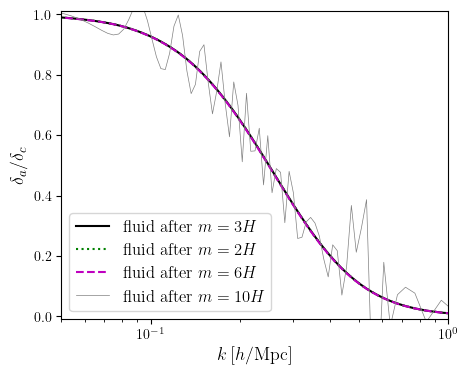

In [ ]:
chi_tk_k = chiCDM.get_transfer(z=0.)

# Pk_ax = np.array([chiCDM.pk_lin(k*h,0.)*h**3 for k in kk])

kEval=chi_tk_k['k (h/Mpc)']
d_ax_k=-chi_tk_k['d_scf']
d_cdm_k=-chi_tk_k['d_cdm']

plt.figure(figsize=(5,4))
# ratio_3 = chi_tk_k['d_scf']/chi_tk_k['d_cdm']
plt.semilogx(kEval, ratio_3,'k',label=r'fluid after $m=3H$')

# ratio_2 = chi_tk_k['d_scf']/chi_tk_k['d_cdm']
plt.semilogx(kEval, ratio_2,'g:',label=r'fluid after $m=2H$')

# ratio_6 = chi_tk_k['d_scf']/chi_tk_k['d_cdm']
plt.semilogx(kEval, ratio_6,'m--',label=r'fluid after $m=6H$')


# ratio_10 = chi_tk_k['d_scf']/chi_tk_k['d_cdm']
plt.semilogx(kEval, ratio_10,'gray', linewidth = 0.5,label=r'fluid after $m=10H$')


plt.xlabel(r'$k\,[h/\mathrm{Mpc}]$', fontsize=13)
plt.ylabel(r'$\delta_a/\delta_c$', fontsize=13)
plt.legend(loc='lower left', fontsize=12)

plt.xlim([5.e-2,1])
plt.ylim([-0.01, 1.01])


plt.show()


--- 
plot with kJ

In [3]:
h = 0.67810
_H0_ = 3.336e-04 * h
_ev_to_HO_ = 1.56e29 / _H0_
common_settings = {
'h':h,
'z_reio':7.6711,
'YHe':0.25,
'perturbations_verbose':0,
'background_verbose':0,
'output':'mPk,mTk, vTk',
'P_k_max_1/Mpc':100,
'z_max_pk':5,
'format':'class',
'N_ur': 3.046,
'h':0.67810,'z_reio':7.6711,'YHe':0.25,'omega_b':0.02238,
}
chiCDM = Class()
chiCDM.set(common_settings)
m_ev = 1.e-27
fx = 0.06
chiCDM.set({'omega_cdm': 0.12, 'scf_potential': 'axion', 'n_axion': 1, 'f_axion': 0.4, 'Omega_scf': ((fx/(1-fx))*(0.12+0.02238))/h/h, 'm_axion': m_ev * _ev_to_HO_, 
            'tol_shooting_deltax': 1e-4,
            'tol_shooting_deltaF': 1e-4,
            'scf_parameters': '0.05,0.0',  # note: if Omega_scf is set, the parameter entry corresponding to scf_tuning_index is ignored and used for shooting.
            'scf_tuning_index': 0,  # in this example, we shoot over theta_ini in order to adjust Omega_scf.
            'scf_evolve_as_fluid': 'yes',  # if set to yes, will switch for fluid when threshold_scf_fluid_m_over_H is met
            'scf_evolve_like_axionCAMB': 'yes',  # fluid all the time in perts, the option no is currently bugging, to be debugged
            'threshold_scf_fluid_m_over_H': 3,  # threshold_scf_fluid_m_over_H controls when to switch to fluid
            'do_shooting': 'yes',  # controls shooting in general; e.g. theta_s
            'do_shooting_scf': 'yes',  # necessary when log10_axion_ac & log10_fraction_axion_ac are chosen
            'scf_has_perturbations': 'yes',  # for pedagogical purposes only
            'use_big_theta_scf': 'no',  # in perts with the fluid it is often more stable to follow the heat flux rather "Big Theta=(1+w)*Theta" than the velocity divergence "Theta"
            'use_delta_scf_over_1plusw': 'no',
            'attractor_ic_scf': 'no',  # some specific IC for tracker potentials
        })
chiCDM.compute()

pureCDM = Class()
pureCDM.set(common_settings)
pureCDM.set({'N_ur': 3.046, 'omega_cdm':0.12,})
pureCDM.compute()

nuCDM = Class()
nuCDM.set(common_settings)
Mnu= 1.
# Fix omega_m = 0.142
omega_nu = Mnu/93.14
omega_c = 0.142-0.02238-omega_nu
nuCDM.set({
    'omega_cdm':omega_c,
    'N_ur': 2.0328,
    'N_ncdm':1,
    'm_ncdm':Mnu,
    'ncdm_fluid_approximation':1,
})
nuCDM.compute()

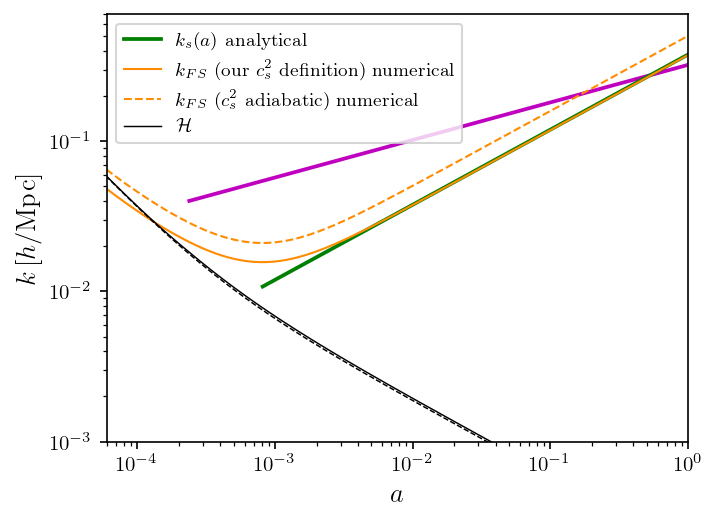

In [53]:
plt.figure(figsize=(5.,3.7), dpi=150)

background = chiCDM.get_background() # load background table
a = 1/(background['z']+1) # read redshift
Ha=background['H [1/Mpc]']/(1.+background['z'])
Ha_chi_int=interp1d(a,Ha)

background = nuCDM.get_background() # load background table
a_nu = 1/(background['z']+1) # read redshift
Ha_nu_cosmo=background['H [1/Mpc]']/(1.+background['z'])


kJ_ULA_z = interp1d(a,8.4e12 * pow(m_ev/h,1/2) * (a)**0.25)



a_ma = 2.38e-4
plt.loglog(a[a>a_ma],kJ_ULA_z(a)[a>a_ma],'m', lw=1.8)
# plt.axhline(0.044, lw=0.5, color='m', ls=':')



kJnu_a = interp1d(a,np.sqrt(5/9)* 5.e-2 * (1./0.1) * pow(a,1/2)* np.sqrt(nuCDM.Omega0_m()/0.3))
Mnu=1.
aNR_nu=1/1890/(Mnu)
# plt.axvline(aNR_nu, c='b', ls='-.', lw=0.5, label=r'$1/(1890 m_\nu)$')
aNR_nu = 8.12e-04
plt.loglog(a[a>aNR_nu],kJnu_a(a)[a>aNR_nu],'g',label=r'$k_s(a)$ analytical', lw=1.8)
plt.loglog(a_numeric,k_FS_nu,'darkorange',label=r'$k_{FS}$ (our $c_s^2$ definition) numerical', linewidth=1)


plt.loglog(a_numeric,k_FS_nu2,'darkorange',ls='--', label=r'$k_{FS}$ ($c_s^2$ adiabatic) numerical', linewidth=1)


plt.loglog(a,Ha/h,'k',label=r'$\mathcal{H}$', lw = 0.7)

plt.loglog(a_nu,Ha_nu_cosmo/h,'k--', lw = 0.7)
# plt.loglog(a_nu,2.12*np.sqrt(Omega_m)*Ha_nu_cosmo/h,'b--', label=r'$k_s(c_s^2=\frac{1}{3})$', lw = 0.7)


plt.xlim([6.e-5,1])
plt.ylim([1.e-3,0.7])
plt.legend(fontsize=9)
plt.xscale('log')
plt.xlabel(r'$a$', fontsize=13)
plt.ylabel(r'$k\,[h/\mathrm{Mpc}]$', fontsize=13)
# plt.savefig('/home/fverdian/class/soundspeed-scripts/figure/ks_a_evolution.pdf',bbox_inches='tight')
#
plt.show()

A ennio viene kdrop del ULAs k=0.044
Il neutrino faccio partire da 10**-2

In [15]:
kJnu_a(a)[a>aNR_nu]

array([0.00869754, 0.00869894, 0.00870035, ..., 0.37799231, 0.37805324,
       0.37811418])

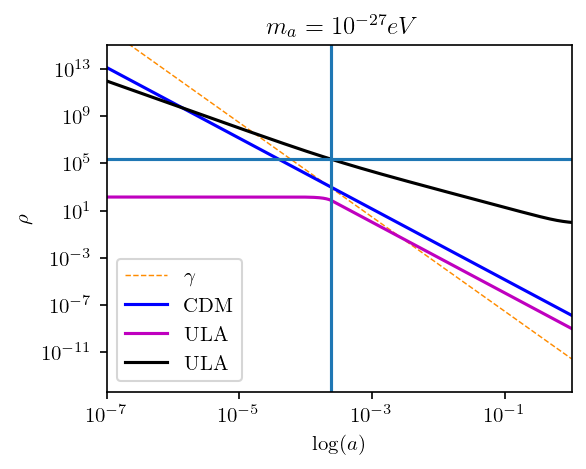

In [46]:
plt.figure(figsize=(4,3), dpi=150)

chibck = chiCDM.get_background() # load background table
a = 1/(chibck['z']+1) # read redshift
rho_cdm=chibck['(.)rho_cdm']
rho_ax=chibck['(.)rho_scf']
rho_g=chibck['(.)rho_g']
rho_crit=chibck['(.)rho_crit']

H_ul_in_H0=chibck['H [1/Mpc]']/chibck['H [1/Mpc]'][-1]


plt.xlabel(r'$a $')
plt.loglog(a,rho_g,'darkorange', linestyle='--',linewidth=0.7, label=r'$\gamma$')
plt.loglog(a,rho_cdm, 'b', label=r'CDM')
plt.loglog(a,rho_ax, 'm', label=r'ULA')

plt.loglog(a,H_ul_in_H0, 'k', label=r'ULA')


plt.axhline(m_ev*_ev_to_HO_/3)


plt.axvline(2.38e-4)

plt.xlim([1.e-7,1])
plt.ylim([None,1.e15])
plt.legend(loc='best')
plt.xscale('log')
plt.xlabel(r'$\log(a)$')
plt.ylabel(r'$\rho$')
plt.title(r'$m_a = 10^{-27}eV$')
plt.show()


In [50]:
from scipy.interpolate import interp1d

# Calculate the target value
target_value = m_ev * _ev_to_HO_ / 3

# Create interpolation function to find a when H_ul_in_H0 equals target_value
# Since H_ul_in_H0 is decreasing with a, we need to reverse the arrays
H_interp = interp1d(H_ul_in_H0[::-1], a[::-1], kind='linear', bounds_error=False, fill_value='extrapolate')

# Find the scale factor a when H_ul_in_H0 = target_value
a_target = H_interp(target_value)

print(f"Target value: {target_value:.2e}")
print(f"Scale factor a when H_ul_in_H0 = m_ev*_ev_to_HO_/3: {a_target:.2e}")

# Find the minimum value of k_FS_nu2 and its corresponding scale factor
min_k_FS_nu2_idx = np.argmin(k_FS_nu2)
min_k_FS_nu2_value = k_FS_nu2[min_k_FS_nu2_idx]
a_min_k_FS_nu2 = a_numeric[min_k_FS_nu2_idx]

print(f"Minimum k_FS_nu2 value: {min_k_FS_nu2_value:.2e}")
print(f"Scale factor a at minimum k_FS_nu2: {a_min_k_FS_nu2:.2e}")


Target value: 2.30e+05
Scale factor a when H_ul_in_H0 = m_ev*_ev_to_HO_/3: 2.38e-04
Minimum k_FS_nu2 value: 2.10e-02
Scale factor a at minimum k_FS_nu2: 8.12e-04


0.37322231295937885


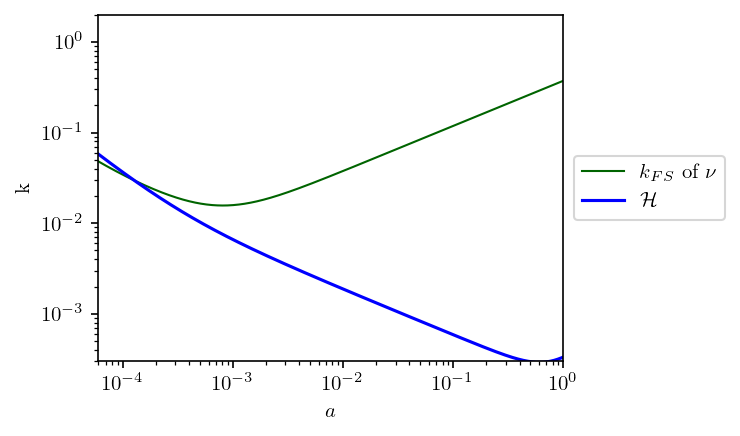

In [27]:
plt.figure(figsize=(4,3), dpi=150)

background = nuCDM.get_background() # load background table
a = 1/(background['z']+1) # read redshift
rho_cdm=background['(.)rho_cdm']

Ha=background['H [1/Mpc]']/(1.+background['z'])
Ha_chi_int=interp1d(a,Ha)
background = nuCDM.get_background() # load background table
background_a = 1/(background['z']+1) # read redshift
rho_nu=background['(.)rho_ncdm[0]']
Omega_m=(background['(.)rho_cdm']+background['(.)rho_b']+rho_nu)/background['(.)rho_crit']

plt.xlabel(r'$a $')
# compute kFS for neutrinos
h = nuCDM.h() # get reduced Hubble for conversions to 1/Mpc
background = nuCDM.get_background() # load background table
rho_nu=background['(.)rho_ncdm[0]']
p_nu=background['(.)p_ncdm[0]']
drho_nu_da = np.gradient(rho_nu, a)
dp_nu_da = np.gradient(p_nu, a)
cFS2_nu=dp_nu_da/drho_nu_da
Ha=background['H [1/Mpc]']/(1.+background['z'])
Ha_nu_int=interp1d(a,Ha)

k_FS_nu=np.sqrt(3/2*Omega_m)*Ha/h/(np.sqrt(9/5)*np.sqrt(cFS2_nu))
k_FS_nu2=np.sqrt(3/2*Omega_m)*Ha/h/(np.sqrt(cFS2_nu))

# plt.loglog(background_a,cFS2_nu,label=r'cFS')
a_numeric =a 
plt.loglog(a,k_FS_nu,'darkgreen',label=r'$k_{FS}$ of $\nu$', linewidth=1)

plt.loglog(a,Ha/h,'blue',label=r'$\mathcal{H}$')

# plt.semilogx(a,cFS2_nu,'blue',label=r'$\mathcal{H}$')

# plt.axvline(x=1/(0.61+1), color='k', linewidth=0.3)

k_FS_nu_int_z=interp1d(1/a-1,k_FS_nu)

plt.xlim([6.e-5,1])
plt.ylim([3.e-4,2])
print(k_FS_nu_int_z(0))
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.xscale('log')
plt.xlabel(r'$a$')
plt.ylabel(r'k')
# plt.savefig('/home/fverdian/class/soundspeed-scripts/figure/kFS_kF_Mnu01.pdf',bbox_inches='tight')
#
plt.show()

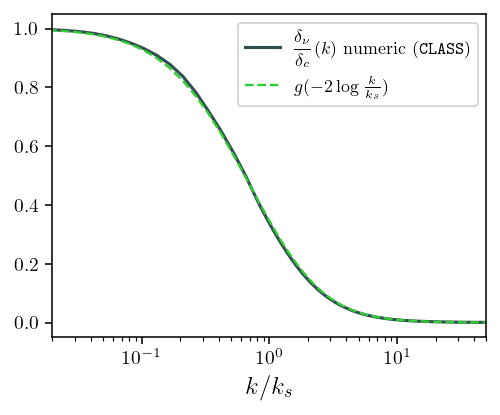

In [56]:
zeval = 0.5

def g_an(t):
    return  1 + 6 * np.exp(-t) * np.cos(np.sqrt(6) * np.exp(-t / 2)) * sici(np.sqrt(6) * np.exp(-t / 2))[1] - 3 * np.exp(-t) * np.pi * np.sin(np.sqrt(6) * np.exp(-t / 2)) + 6 * np.exp(-t) * np.sin(np.sqrt(6) * np.exp(-t / 2)) * sici(np.sqrt(6) * np.exp(-t / 2))[0]



nu_tk_k = nuCDM.get_transfer(z=zeval)
T_ratio_nu =nu_tk_k['d_ncdm[0]']/ nu_tk_k['d_cdm']
mnu = Mnu/3


plt.figure(figsize=(4.,3), dpi=140)


plt.plot(kEval/kJnu, T_ratio_nu,'darkslategray', linewidth=1.6,label=r'$\displaystyle\frac{\delta_\nu}{\delta_c}(k)$ numeric ($\texttt{CLASS}$)')
plt.plot(kEval/kJnu, g_an(-2*np.log(kEval/(kJnu_a(0.66)))),'limegreen', linestyle='--', linewidth=1.2,label=r'$g(-2\log \frac{k}{k_s})$ ')


plt.xscale('log')
plt.xlabel(r'$k/k_s$', fontsize=13)
plt.legend(loc='best', fontsize=9)
plt.xlim([2.e-2,5.e1])
# plt.savefig('/home/fverdian/class/soundspeed-scripts/figure/lincompare.pdf', bbox_inches='tight')
plt.show()

In [ ]:
h = 0.67810
_H0_ = 3.336e-04 * h
_ev_to_HO_ = 1.56e29 / _H0_
common_settings = {
'h':h,
'z_reio':7.6711,
'YHe':0.25,
'perturbations_verbose':0,
'background_verbose':0,
'output':'mPk,mTk, vTk',
'P_k_max_1/Mpc':100,
'z_max_pk':5,
'format':'class',
'N_ur': 3.046,
'h':0.67810,'z_reio':7.6711,'YHe':0.25,'omega_b':0.02238,
}
chiCDM = Class()
chiCDM.set(common_settings)
m_ev = 1.e-27
fx = 0.06
chiCDM.set({'omega_cdm': 0.12, 'scf_potential': 'axion', 'n_axion': 1, 'f_axion': 0.4, 'Omega_scf': ((fx/(1-fx))*(0.12+0.02238))/h/h, 'm_axion': m_ev * _ev_to_HO_, 
            'tol_shooting_deltax': 1e-4,
            'tol_shooting_deltaF': 1e-4,
            'scf_parameters': '0.05,0.0',  # note: if Omega_scf is set, the parameter entry corresponding to scf_tuning_index is ignored and used for shooting.
            'scf_tuning_index': 0,  # in this example, we shoot over theta_ini in order to adjust Omega_scf.
            'scf_evolve_as_fluid': 'yes',  # if set to yes, will switch for fluid when threshold_scf_fluid_m_over_H is met
            'scf_evolve_like_axionCAMB': 'yes',  # fluid all the time in perts, the option no is currently bugging, to be debugged
            'threshold_scf_fluid_m_over_H': 3,  # threshold_scf_fluid_m_over_H controls when to switch to fluid
            'do_shooting': 'yes',  # controls shooting in general; e.g. theta_s
            'do_shooting_scf': 'yes',  # necessary when log10_axion_ac & log10_fraction_axion_ac are chosen
            'scf_has_perturbations': 'yes',  # for pedagogical purposes only
            'use_big_theta_scf': 'no',  # in perts with the fluid it is often more stable to follow the heat flux rather "Big Theta=(1+w)*Theta" than the velocity divergence "Theta"
            'use_delta_scf_over_1plusw': 'no',
            'attractor_ic_scf': 'no',  # some specific IC for tracker potentials
        })
chiCDM.compute()

pureCDM = Class()
pureCDM.set(common_settings)
pureCDM.set({'N_ur': 3.046, 'omega_cdm':0.12,})
pureCDM.compute()

nuCDM = Class()
nuCDM.set(common_settings)
Mnu= 1.
# Fix omega_m = 0.142
omega_nu = Mnu/93.14
omega_c = 0.142-0.02238-omega_nu
nuCDM.set({
    'omega_cdm':omega_c,
    'N_ur': 2.0328,
    'N_ncdm':1,
    'm_ncdm':Mnu,
    'ncdm_fluid_approximation':1,
})
nuCDM.compute()

----

In [14]:
kk = np.logspace(-1.5,0,200); h = chiCDM.h(); Pk_list=[]

chiCDM.set({
    'm_axion': 1.e-10 * _ev_to_HO_,  # in units of H0
})
chiCDM.compute()



Pk1 = [chiCDM.pk_lin(k*h,0.5)*h**3 for k in kk]

chiCDM.set({
    'm_axion': 3.e-26 * _ev_to_HO_,  # in units of H0
    'Omega_scf' : (0.15*0.05)/h/h,
})
chiCDM.compute()
Pk2= [chiCDM.pk_lin(k*h,0.5)*h**3 for k in kk]


Running CLASS version v3.2.0
Computing background
Chose ndf15 as generic_evolver
 -> age = 13.512290 Gyr
 -> conformal age = 13780.422387 Mpc
 -> H0 = 67.810000 km/s/Mpc
 -> N_eff = 3.044 (summed over all species that are non-relativistic at early times) 
 -> radiation/matter equality at z = 3642.267036
    corresponding to conformal time = 105.405085 Mpc
 ---------------------------- Budget equation ----------------------- 
 ---> Nonrelativistic Species 
-> Bayrons                        Omega = 0.0486773       , omega = 0.0223828      
-> Cold Dark Matter               Omega = 0.260972        , omega = 0.12           
-> Axion DM                       Omega = 0.0217477       , omega = 0.01           
 ---> Relativistic Species 
-> Photons                        Omega = 5.37815e-05     , omega = 2.47298e-05    
-> Ultra-relativistic relics      Omega = 3.71799e-05     , omega = 1.70961e-05    
 ---> Other Content 
-> Cosmological Constant          Omega = 0.668512        , omega = 0.3

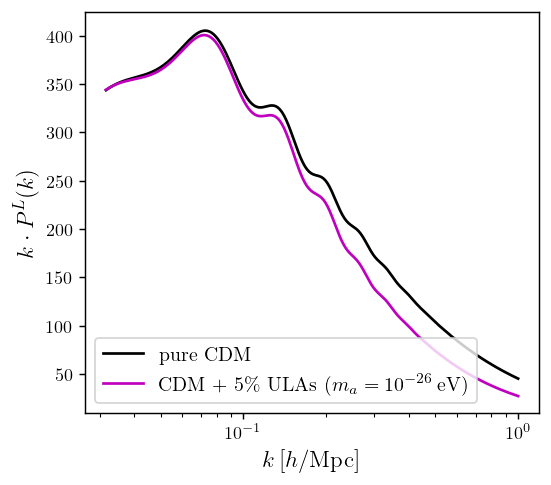

In [16]:
plt.figure(figsize=(4.5,4), dpi=130)
plt.plot(kk, kk*Pk1, 'k', label=f'pure CDM')

plt.plot(kk, kk*Pk2, 'm', label=r'CDM + $5\%$ ULAs ($m_a=10^{-26}\,\mathrm{eV})$')


plt.xlabel(r'$k\,[h/\mathrm{Mpc}]$', fontsize=13)
plt.ylabel(r'$k\cdot P^L(k)$', fontsize=13)
plt.ylim([1.e1,None])
plt.legend(loc='lower left', fontsize=11)
plt.xscale('log')
# plt.ylim([1.,None])

plt.show()
